In [1]:
import matplotlib.pyplot as plt
import numpy as np
import conf_file as conf
import KF

# loading the data
ground_truth = np.loadtxt("data/ground_truth_3d_position.csv", delimiter=",", skiprows=1)
sensor_3d    = np.loadtxt("data/measurements_3d_position_sensor.csv", delimiter=",", skiprows=1)

# function to evaluate RMS ATE as a metric
def rms_ate(estimated, ground_truth):
    errors = estimated - ground_truth
    position_errors = np.linalg.norm(errors, axis=1)
    rms_ate = np.sqrt(np.mean(position_errors**2))
    return rms_ate

# Plot of raw measurements

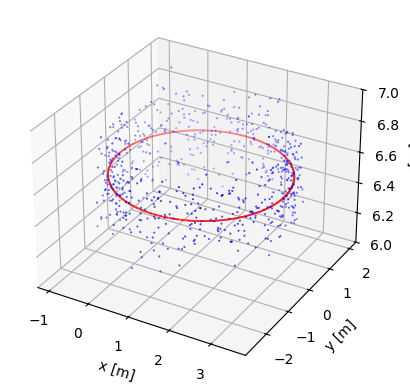

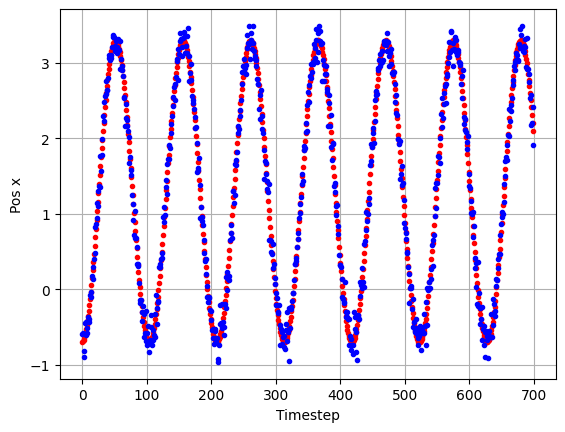

In [2]:
# plotting the 3D trajectory
fig = plt.figure()
#plt.title("Ground truth and 3d measurements")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ground_truth[:,0],ground_truth[:,1],ground_truth[:,2], s=0.1, color='red')
ax.scatter(sensor_3d[:,0],sensor_3d[:,1],sensor_3d[:,2], s=0.2, color='blue')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_zlim(6,7)
plt.show()

# showing the x coordinates
plt.figure()
plt.plot(ground_truth[:,0],'.',color='red')
plt.plot(sensor_3d[:,0],'.',color='blue')
plt.xlabel("Timestep")
plt.ylabel("Pos x")
plt.grid()
plt.show()

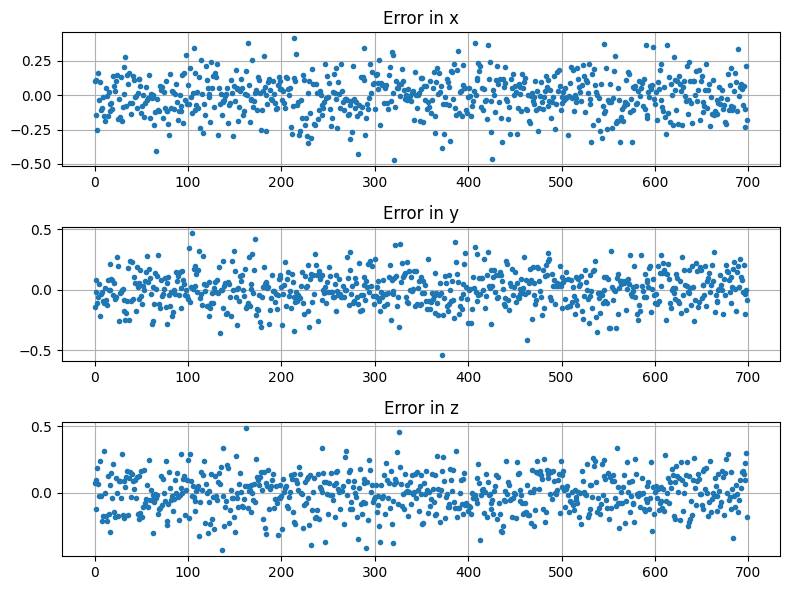

Mean error:  -0.005 m ,  0.008 m ,  -0.002 m
Variance:  0.020 m^2 ,  0.020 m^2 ,  0.020 m^2
RMS ATE:  0.246


In [3]:
# plot of the estimation error
fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].plot(sensor_3d[:,0]-ground_truth[:,0],'.')
ax[0].set_title("Error in x")
ax[0].grid()

ax[1].plot(sensor_3d[:,1]-ground_truth[:,1],'.')
ax[1].set_title("Error in y")
ax[1].grid()

ax[2].plot(sensor_3d[:,2]-ground_truth[:,2],'.')
ax[2].set_title("Error in z")
ax[2].grid()

plt.tight_layout()
plt.show()

# statistics
print("Mean error: ","%.3f" % np.mean(sensor_3d[:,0]-ground_truth[:,0]),"m",
    ", ", "%.3f" % np.mean(sensor_3d[:,1]-ground_truth[:,1]),"m",
    ", ", "%.3f" % np.mean(sensor_3d[:,2]-ground_truth[:,2]),"m")
print("Variance: ","%.3f" % np.var(sensor_3d[:,0]-ground_truth[:,0]),"m^2",
    ", ", "%.3f" % np.var(sensor_3d[:,1]-ground_truth[:,1]),"m^2",
    ", ", "%.3f" % np.var(sensor_3d[:,2]-ground_truth[:,2]),"m^2")
# RMS ATE
print("RMS ATE: ", "%.3f" % rms_ate(sensor_3d, ground_truth))

# KF with 3D position sensor
### Initial conditions A

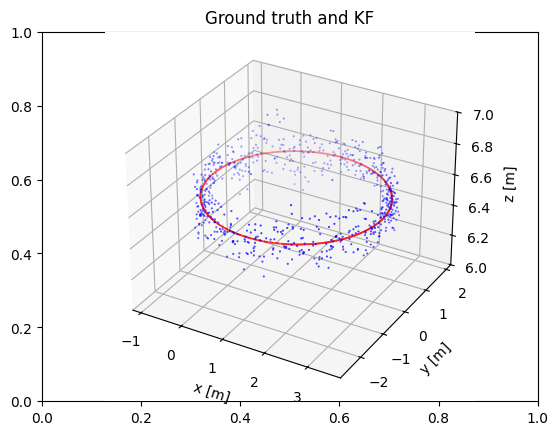

In [4]:
# Kalman filter
P = np.eye(conf.nx)
x = np.array([-0.7, -0.3, 6.6, 0, 0, 0])
x_KF_A = np.zeros((np.size(sensor_3d[:,0]), conf.nx))
for i in range(np.size(sensor_3d[:,0])):
    # prediction step
    x, P = KF.prediction(x, conf.A1, P, conf.Q1)
    # update step
    x, P = KF.update(x, sensor_3d[i,:], conf.H1, P, conf.R1, conf.nx)
    # storing the results
    x_KF_A[i, :] = x

# 3D plot
fig = plt.figure()
plt.title("Ground truth and KF")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ground_truth[:,0],ground_truth[:,1],ground_truth[:,2], s=0.1, color='red')
ax.scatter(x_KF_A[:,0],x_KF_A[:,1],x_KF_A[:,2], s=0.2, color='blue')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_zlim(6,7)
plt.show()

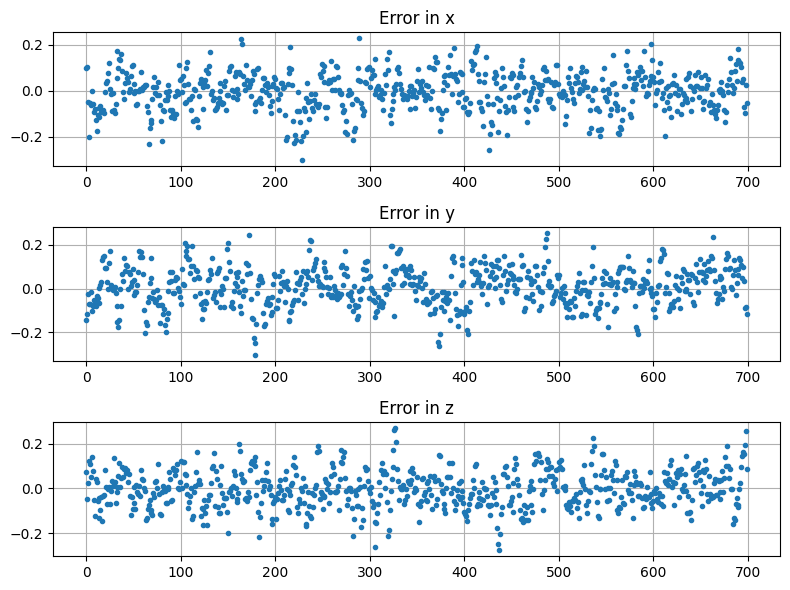

In [5]:
# plot of the estimation error
fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].plot(x_KF_A[:,0]-ground_truth[:,0],'.')
ax[0].set_title("Error in x")
ax[0].grid()

ax[1].plot(x_KF_A[:,1]-ground_truth[:,1],'.')
ax[1].set_title("Error in y")
ax[1].grid()

ax[2].plot(x_KF_A[:,2]-ground_truth[:,2],'.')
ax[2].set_title("Error in z")
ax[2].grid()

plt.tight_layout()
plt.show()

In [7]:
# statistics
print("Mean error: ","%.3f" % np.mean(x_KF_A[:,0]-ground_truth[:,0]),"m",
    ", ", "%.3f" % np.mean(x_KF_A[:,1]-ground_truth[:,1]),"m",
    ", ", "%.3f" % np.mean(x_KF_A[:,2]-ground_truth[:,2]),"m")
print("Variance: ","%.3f" % np.var(x_KF_A[:,0]-ground_truth[:,0]),"m^2",
    ", ", "%.3f" % np.var(x_KF_A[:,1]-ground_truth[:,1]),"m^2",
    ", ", "%.3f" % np.var(x_KF_A[:,2]-ground_truth[:,2]),"m^2")
# RMS ATE
print("RMS ATE: ", "%.3f" % rms_ate(x_KF_A[:,:3],ground_truth))

Mean error:  -0.004 m ,  0.009 m ,  -0.002 m
Variance:  0.007 m^2 ,  0.008 m^2 ,  0.007 m^2
RMS ATE:  0.146


### INITIAL CONDITIONS B

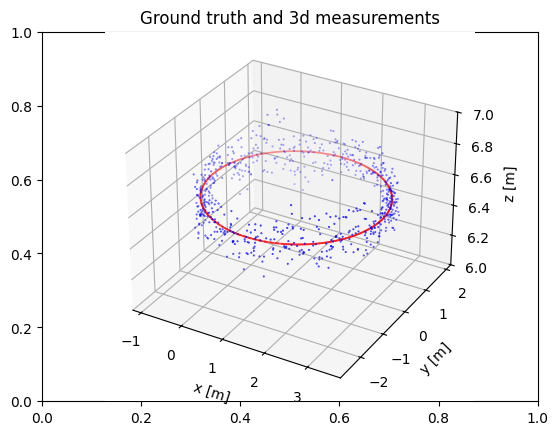

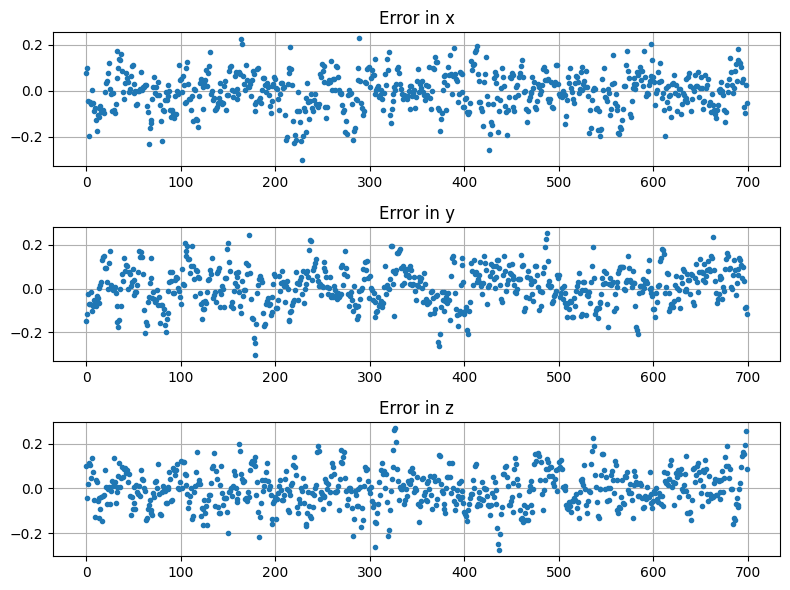

In [8]:
# Kalman filter
P = np.eye(conf.nx)
x = np.array([-1.8, -0.5, 7.9, 0, 0, 0])
x_KF_B = np.zeros((np.size(sensor_3d[:,0]), conf.nx))
for i in range(np.size(sensor_3d[:,0])):
    # prediction step
    x, P = KF.prediction(x, conf.A1, P, conf.Q1)
    # update step
    x, P = KF.update(x, sensor_3d[i,:], conf.H1, P, conf.R1, conf.nx)
    # storing the results
    x_KF_B[i, :] = x

# 3D plot
fig = plt.figure()
plt.title("Ground truth and 3d measurements")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ground_truth[:,0],ground_truth[:,1],ground_truth[:,2], s=0.1, color='red')
ax.scatter(x_KF_B[:,0],x_KF_B[:,1],x_KF_B[:,2], s=0.2, color='blue')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_zlim(6,7)
plt.show()

# plot of the estimation error
fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].plot(x_KF_B[:,0]-ground_truth[:,0],'.')
ax[0].set_title("Error in x")
ax[0].grid()

ax[1].plot(x_KF_B[:,1]-ground_truth[:,1],'.')
ax[1].set_title("Error in y")
ax[1].grid()

ax[2].plot(x_KF_B[:,2]-ground_truth[:,2],'.')
ax[2].set_title("Error in z")
ax[2].grid()

plt.tight_layout()
plt.show()

In [9]:
# statistics
print("Mean error: ","%.3f" % np.mean(x_KF_B[:,0]-ground_truth[:,0]),"m",
    ", ", "%.3f" % np.mean(x_KF_B[:,1]-ground_truth[:,1]),"m",
    ", ", "%.3f" % np.mean(x_KF_B[:,2]-ground_truth[:,2]),"m")
print("Variance: ","%.3f" % np.var(x_KF_B[:,0]-ground_truth[:,0]),"m^2",
    ", ", "%.3f" % np.var(x_KF_B[:,1]-ground_truth[:,1]),"m^2",
    ", ", "%.3f" % np.var(x_KF_B[:,2]-ground_truth[:,2]),"m^2")
# RMS ATE
print("RMS ATE: ", "%.3f" % rms_ate(x_KF_B[:,:3],ground_truth))

Mean error:  -0.004 m ,  0.009 m ,  -0.002 m
Variance:  0.007 m^2 ,  0.008 m^2 ,  0.007 m^2
RMS ATE:  0.146
